# Diabetes Clustering

This notebook explores unsupervised structure in the diabetes dataset using clustering.

**Goals**
- Load the cleaned dataset
- Scale numeric features
- Select a reasonable number of clusters
- Fit a clustering model
- Inspect cluster profiles

**Notes**
- This notebook uses the cleaned dataset and does **not** redo preprocessing.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("../data/processed/diabetes_clean.csv")
TARGET_COL = "CLASS"
ID_COL_CANDIDATES = ["ID", "No_Pation"]
RANDOM_STATE = 42


## 1. Load Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Missing data file: {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

id_cols = [c for c in ID_COL_CANDIDATES if c in df.columns]
df = df.drop(columns=id_cols, errors="ignore")

# Drop target for unsupervised learning
if TARGET_COL in df.columns:
    df = df.drop(columns=[TARGET_COL])

numeric_cols = df.select_dtypes(include="number").columns

if len(numeric_cols) == 0:
    raise ValueError("No numeric columns found for clustering.")

X = df[numeric_cols].copy()

print(f"Rows: {len(df):,} | Numeric features: {len(numeric_cols)}")
print("Numeric feature columns:", list(numeric_cols))


Rows: 1,000 | Numeric features: 10
Numeric feature columns: ['AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']


## 2. Scale Features

In [3]:
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=numeric_cols, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 3. Choose Number of Clusters

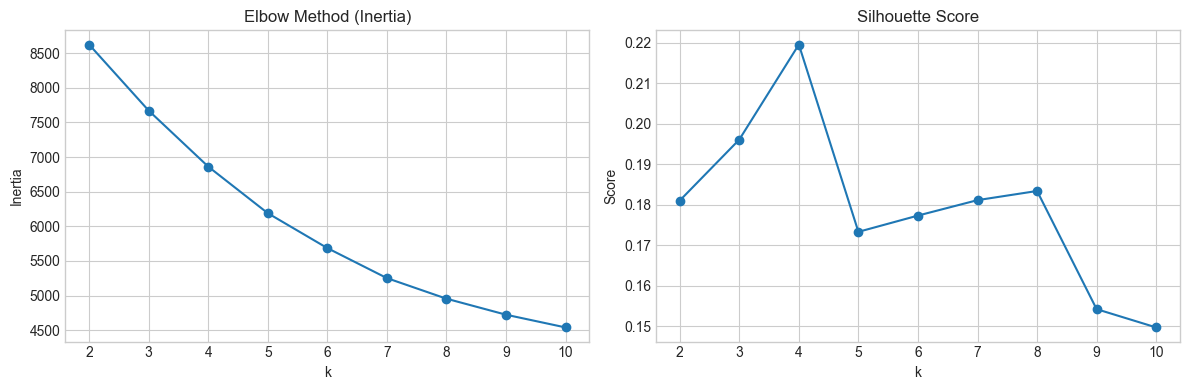

Best k by silhouette: 4


In [4]:
n_samples = X_scaled.shape[0]
if n_samples < 2:
    raise ValueError("Not enough samples for clustering.")

max_k = min(10, n_samples - 1)
if max_k < 2:
    raise ValueError("Not enough samples to try k>=2.")

k_values = range(2, max_k + 1)

inertia = []
silhouette = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(k_values, inertia, marker="o")
ax[0].set_title("Elbow Method (Inertia)")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_values, silhouette, marker="o")
ax[1].set_title("Silhouette Score")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

best_k = k_values[int(np.argmax(silhouette))]
print(f"Best k by silhouette: {best_k}")


## 4. Fit KMeans

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(X_scaled)

clustered = X.copy()
clustered["cluster"] = cluster_labels

print(clustered["cluster"].value_counts().sort_index())


cluster
0    232
1    704
2     50
3     14
Name: count, dtype: int64


## 5. Cluster Visualization (PCA)

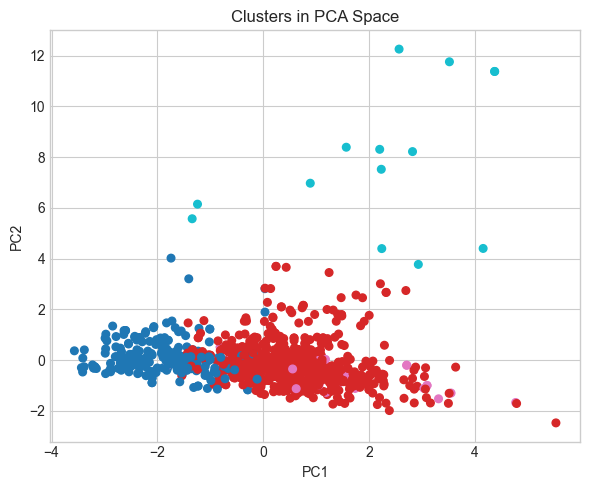

In [10]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="tab10", s=30)
plt.title("Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

## 6. Cluster Profiles

In [7]:
cluster_summary = clustered.groupby("cluster")[numeric_cols].mean()

display(cluster_summary)

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
cluster,,,,,,,,,,
0,54.428571,22.214286,421.928571,7.950000,4.921429,2.964286,1.078571,2.614286,1.285714,30.828571
1,56.981258,5.007286,64.507363,9.166479,4.900830,2.473240,1.202945,2.573815,2.023963,31.462892
2,42.682008,4.490795,62.129707,5.533473,4.740586,1.927197,1.217782,2.721967,1.358996,23.613556


## 7. Save Cluster Assignments

In [8]:
OUTPUT_PATH = Path("../data/processed/diabetes_clusters.csv")
clustered.to_csv(OUTPUT_PATH, index=False)
print(f"Saved cluster assignments to: {OUTPUT_PATH.resolve()}")

Saved cluster assignments to: /Users/abhaydhakal/Documents/diabetes_prediction/data/processed/diabetes_clusters.csv
